In [2]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
torch.cuda.is_available()

True

In [3]:
from keras.models import Sequential, Model
from keras.layers import Dense, Input, Flatten
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam, RMSprop
from keras.metrics import Accuracy
from keras.datasets import fashion_mnist

In [24]:
(x_train, y_train), (x_test, y_true) = fashion_mnist.load_data()

In [25]:
def build_model(activation: str = 'relu'):
  model = Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(units=128, activation=activation),
    Dense(128, activation=activation),
    Dense(128, activation=activation),
    Dense(10, activation='softmax'), #10 categories of dogs
    # Dense(1,activation='linear'), # 1 stock price 
    # Dense(1, activation='sigmoid') # 1 "boolean"
  
  ])


  model.compile(optimizer=Adam(), 
                loss=SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

  return model


model = build_model()
model.summary()


  

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:

model.fit(
  x_train, 
  y_train,
  batch_size=1024,
  epochs=40,
  validation_split=0.2
)

Epoch 1/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9562 - loss: 0.1179 - val_accuracy: 0.8708 - val_loss: 0.6521
Epoch 2/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9540 - loss: 0.1228 - val_accuracy: 0.8721 - val_loss: 0.6301
Epoch 3/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9557 - loss: 0.1204 - val_accuracy: 0.8725 - val_loss: 0.6781
Epoch 4/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9532 - loss: 0.1286 - val_accuracy: 0.8759 - val_loss: 0.6363
Epoch 5/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9536 - loss: 0.1261 - val_accuracy: 0.8648 - val_loss: 0.6569
Epoch 6/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9521 - loss: 0.1292 - val_accuracy: 0.8742 - val_loss: 0.6398
Epoch 7/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9549 - loss: 0.1231 - val_accuracy: 0.8737 - val_loss: 0.6616
Epoch 8/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9548 - loss: 0.1217 - val_accuracy: 0.8735 - val_loss

model.history:  {'accuracy': [0.8744791746139526, 0.8774374723434448, 0.8816249966621399, 0.8838541507720947, 0.8878541588783264, 0.8899999856948853, 0.8909375071525574, 0.8929374814033508, 0.8970416784286499, 0.8965416550636292, 0.8994583487510681, 0.8996666669845581, 0.9019791483879089, 0.9035416841506958, 0.9049375057220459, 0.9049166440963745, 0.9059374928474426, 0.9057291746139526, 0.9117500185966492, 0.9102500081062317], 'loss': [0.3434544801712036, 0.3346879184246063, 0.32178154587745667, 0.3129080533981323, 0.3054705560207367, 0.29768598079681396, 0.2923309803009033, 0.2886279821395874, 0.28006497025489807, 0.27841436862945557, 0.27151408791542053, 0.27067217230796814, 0.26339539885520935, 0.2565537989139557, 0.25441253185272217, 0.2555374205112457, 0.25323909521102905, 0.2500571012496948, 0.2395382821559906, 0.239030659198761], 'val_accuracy': [0.8557500243186951, 0.8575833439826965, 0.8620833158493042, 0.8605833053588867, 0.8632500171661377, 0.85916668176651, 0.86558336019515

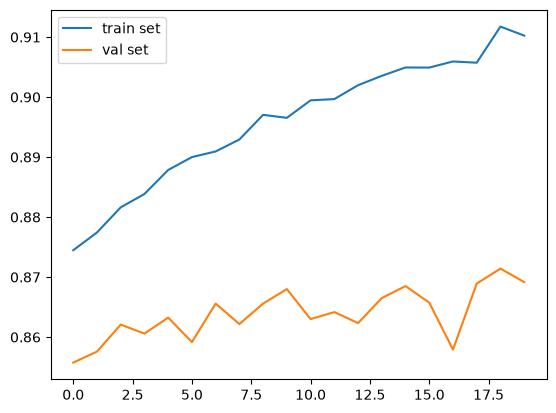

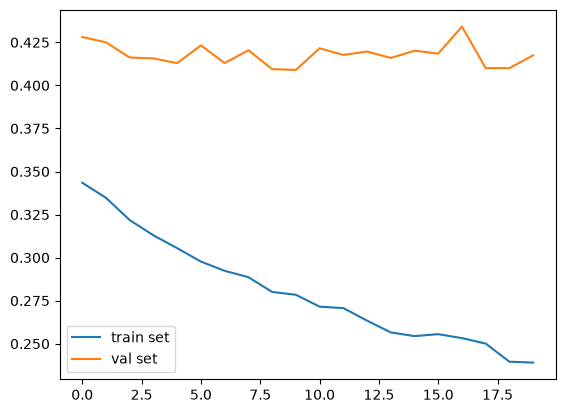

In [19]:

logs = model.history.history
print('model.history: ', logs)
plt.Figure(figsize=(12,7))
# sns.lineplot(logs)
plt.plot(logs['accuracy'], label="train set")
plt.plot(logs['val_accuracy'], label="val set")
plt.legend()
plt.show()

plt.Figure(figsize=(12,7))
# sns.lineplot(logs)
plt.plot(logs['loss'], label="train set")
plt.plot(logs['val_loss'], label="val set")
plt.legend()
plt.show()

In [20]:
y_prediction_probabilities = model.predict(x_test)
y_predictions = np.argmax(y_prediction_probabilities, axis =1)
y_predictions

  1/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([9, 2, 1, ..., 8, 1, 5], shape=(10000,))

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [23]:
print(classification_report(y_true, y_predictions))

NameError: name 'y_true' is not defined

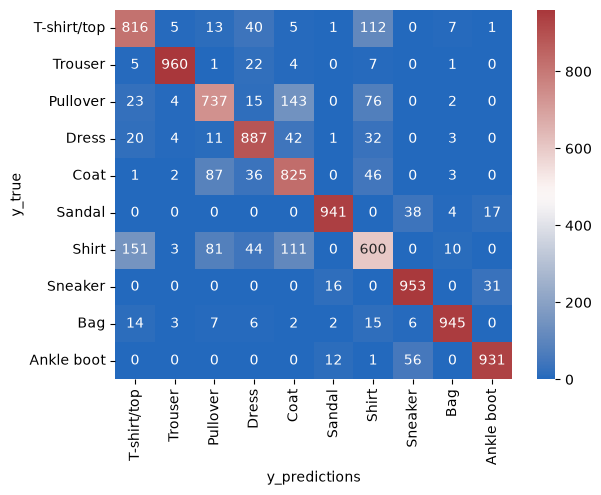

In [ ]:
crosstab = confusion_matrix(y_true,y_predictions)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.Figure(figsize=(24,10))
sns.heatmap(crosstab, cmap="vlag", annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("y_predictions")
plt.ylabel("y_true")
plt.show()

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, train_size=0.8, random_state=24)

print('x_train.shape: ', x_train.shape)
print('x_val.shape: ', x_val.shape)

x_train.shape:  (48000, 28, 28)
x_val.shape:  (12000, 28, 28)


In [47]:
mispredictions = np.where(y_predictions != y_true)
mispredictions

(array([  17,   23,   29, ..., 9979, 9985, 9991], shape=(1405,)),)

AttributeError: 'numpy.ndarray' object has no attribute 'head'

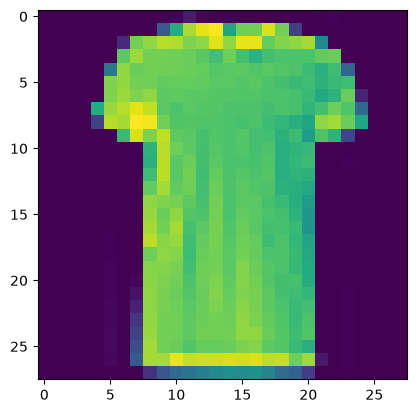

In [ ]:


plt.imshow(misprediction)
